# Quantum Key Distribution with BB84

## Simulating BB84 Quantum Key Distribution with Eavesdropping Detection Using Qiskit

##### This code simulates the BB84 quantum key distribution protocol with Eve eavesdropping by randomly intercepting qubits and measuring them in a random basis. It compares Alice’s and Bob’s sifted keys to calculate the Quantum Bit Error Rate (QBER). If QBER exceeds 11%, the protocol detects possible eavesdropping or noise, flagging the communication as insecure.

In [33]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
import random

# Parameters
n = 20  # number of qubits
backend = Aer.get_backend("qasm_simulator")

# Step 1: Alice's random bits and bases
alice_bits = [random.randint(0, 1) for _ in range(n)]
alice_bases = [random.choice(['Z', 'X']) for _ in range(n)]

# Step 2: Eve's random bases
eve_bases = [random.choice(['Z', 'X']) for _ in range(n)]

# Step 3: Bob's random measurement bases
bob_bases = [random.choice(['Z', 'X']) for _ in range(n)]

# Prepare circuits
circuits = []

for bit, a_base, e_base, b_base in zip(alice_bits, alice_bases, eve_bases, bob_bases):
    qc = QuantumCircuit(1, 1)

    # Alice prepares the qubit
    if bit == 1:
        qc.x(0)
    if a_base == 'X':
        qc.h(0)

    # Eve intercepts and measures
    if e_base == 'X':
        qc.h(0)
    qc.measure(0, 0)

    # Eve sends qubit to Bob (re-encode)
    qc.reset(0)
    eve_bit = 0  # Default fallback
    try:
        eve_result = backend.run(qc, shots=1).result().get_counts().most_frequent()
        eve_bit = int(eve_result)
    except:
        pass

    if eve_bit == 1:
        qc.x(0)
    if e_base == 'X':
        qc.h(0)

    # Bob measures
    if b_base == 'X':
        qc.h(0)
    qc.measure(0, 0)

    circuits.append(qc)

# Run all circuits
job = backend.run(circuits, shots=1)
results = job.result()

bob_results = []
for qc in circuits:
    counts = results.get_counts(qc)
    measured_bit = int(max(counts, key=counts.get))
    bob_results.append(measured_bit)

# Key sifting (match bases)
final_key_alice = []
final_key_bob = []
errors = 0
sifted = 0

for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        sifted += 1
        final_key_alice.append(alice_bits[i])
        final_key_bob.append(bob_results[i])
        if alice_bits[i] != bob_results[i]:
            errors += 1

# QBER calculation
qber = (errors / sifted) * 100 if sifted > 0 else 0

# Display results
print("Alice's bits:      ", alice_bits)
print("Alice's bases:     ", alice_bases)
print("Eve's bases:       ", eve_bases)
print("Bob's bases:       ", bob_bases)
print("Bob's measurements:", bob_results)
print("\nSifted key (Alice):", final_key_alice)
print("Sifted key (Bob):  ", final_key_bob)
print(f"\nQBER: {qber:.2f}%")
print("Eavesdropping Detected!" if qber > 11 else "Secure Communication ✅")


Alice's bits:       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1]
Alice's bases:      ['Z', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'Z', 'X', 'X', 'Z', 'Z']
Eve's bases:        ['Z', 'X', 'Z', 'X', 'X', 'X', 'X', 'X', 'Z', 'Z', 'X', 'X', 'X', 'X', 'X', 'X', 'Z', 'X', 'X', 'Z']
Bob's bases:        ['X', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'Z', 'Z', 'Z']
Bob's measurements: [0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1]

Sifted key (Alice): [0, 1, 0, 0, 1, 0, 1, 1, 1]
Sifted key (Bob):   [0, 0, 0, 1, 1, 0, 1, 1, 1]

QBER: 22.22%
Eavesdropping Detected!


## QBER Analysis in BB84: Impact of Eavesdropping on Quantum Communication Integrity

##### This script simulates the BB84 protocol over multiple runs to statistically compare the Quantum Bit Error Rate (QBER) with and without eavesdropping. It models Eve's presence as introducing random bit flips when her basis differs from Alice’s. The results are plotted to visually show how QBER rises significantly when eavesdropping is simulated, crossing the 11% detection threshold.

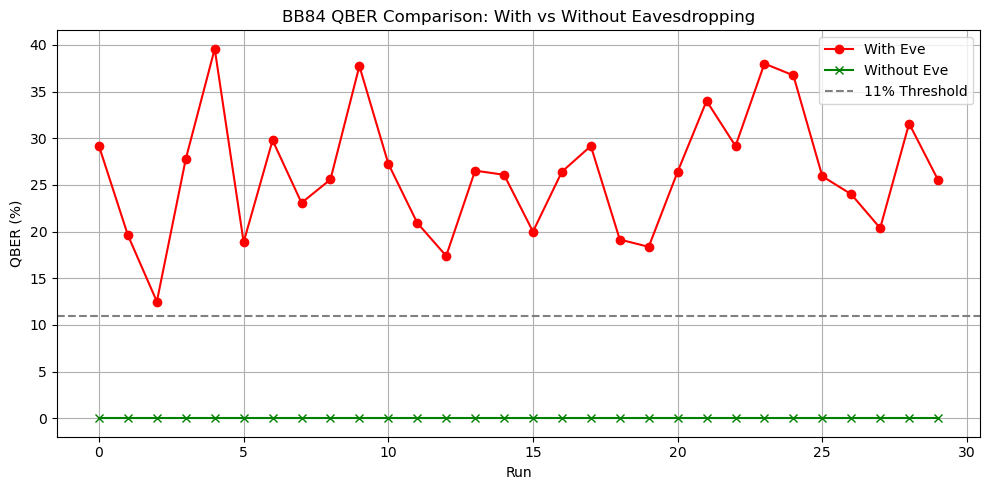

In [37]:
import random
import matplotlib.pyplot as plt

def run_bb84(n=100, with_eve=True):
    alice_bits = [random.randint(0, 1) for _ in range(n)]
    alice_bases = [random.choice(['Z', 'X']) for _ in range(n)]
    bob_bases = [random.choice(['Z', 'X']) for _ in range(n)]
    eve_bases = [random.choice(['Z', 'X']) for _ in range(n)] if with_eve else [''] * n

    errors = 0
    sifted = 0

    for i in range(n):
        alice_bit = alice_bits[i]
        a_base = alice_bases[i]
        b_base = bob_bases[i]
        e_base = eve_bases[i]

        # Simulate Eve's disturbance
        bit = alice_bit
        if with_eve and e_base != a_base:
            bit = bit ^ 1 if random.random() < 0.5 else bit  # flip with 50% chance

        # Bob measures
        if a_base == b_base:
            sifted += 1
            if bit != alice_bit:
                errors += 1

    qber = (errors / sifted) * 100 if sifted > 0 else 0
    return qber

# Run simulations
rounds = 30
qbers_eve = [run_bb84(with_eve=True) for _ in range(rounds)]
qbers_no_eve = [run_bb84(with_eve=False) for _ in range(rounds)]

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(qbers_eve, label="With Eve", marker='o', color='red')
plt.plot(qbers_no_eve, label="Without Eve", marker='x', color='green')
plt.axhline(y=11, color='gray', linestyle='--', label="11% Threshold")
plt.xlabel("Run")
plt.ylabel("QBER (%)")
plt.title("BB84 QBER Comparison: With vs Without Eavesdropping")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Classical AI-Based Detection

## Loading and Inspecting the UNSW-NB15 Network Intrusion Detection Dataset

##### This code imports the UNSW-NB15 dataset, a labeled network intrusion detection dataset with features such as source/destination IPs, ports, protocols, packet counts, and attack labels. It defines the column names manually and reads the CSV while skipping the header row. Finally, it prints the dataset shape and shows a preview to verify successful loading

In [39]:
import pandas as pd

# Define column names (trimmed spaces and corrected typos)
cols = ["srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl", "dttl", "sloss", "dloss",
        "service", "Sload", "Dload", "Spkts", "Dpkts", "swin", "dwin", "stcpb", "dtcpb", "smeansz", "dmeansz",
        "trans_depth", "res_bdy_len", "Sjit", "Djit", "Stime", "Ltime", "Sintpkt", "Dintpkt", "tcprtt", "synack",
        "ackdat", "is_sm_ips_ports", "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src",
        "ct_srv_dst", "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
        "attack_cat", "Label"]

# Load the CSV file (note: added comma after filename, and fixed spacing)
df = pd.read_csv("UNSW-NB15_1.csv", names=cols, skiprows=1)

# Show dataset shape and first few rows
print(df.shape)
df.head()


C:\Users\Probook\AppData\Local\Temp\ipykernel_25464\3932766549.py:12: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("UNSW-NB15_1.csv", names=cols, skiprows=1)


(700000, 49)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,...,0,2,4,2,3,1,1,2,NaN,0


## AI-Based Intrusion Detection Using Random Forest on the UNSW-NB15 Dataset

##### This code implements a machine learning pipeline for detecting network intrusions using the UNSW-NB15 dataset. It begins by preprocessing the dataset, encoding categorical variables, and optionally sampling data for performance efficiency. A Random Forest classifier is then trained on labeled features to predict whether network traffic is normal or malicious. The model’s performance is evaluated through classification metrics and a confusion matrix. Additionally, feature importance analysis highlights the most influential network characteristics contributing to the predictions.

C:\Users\Probook\AppData\Local\Temp\ipykernel_25464\1874414202.py:22: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("UNSW-NB15_1.csv", names=cols, skiprows=1)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14507
           1       0.93      0.97      0.95       493

    accuracy                           1.00     15000
   macro avg       0.96      0.98      0.97     15000
weighted avg       1.00      1.00      1.00     15000



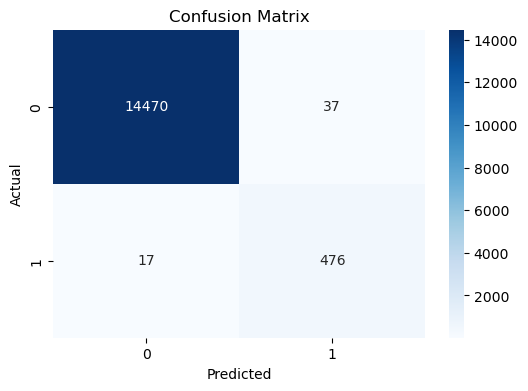

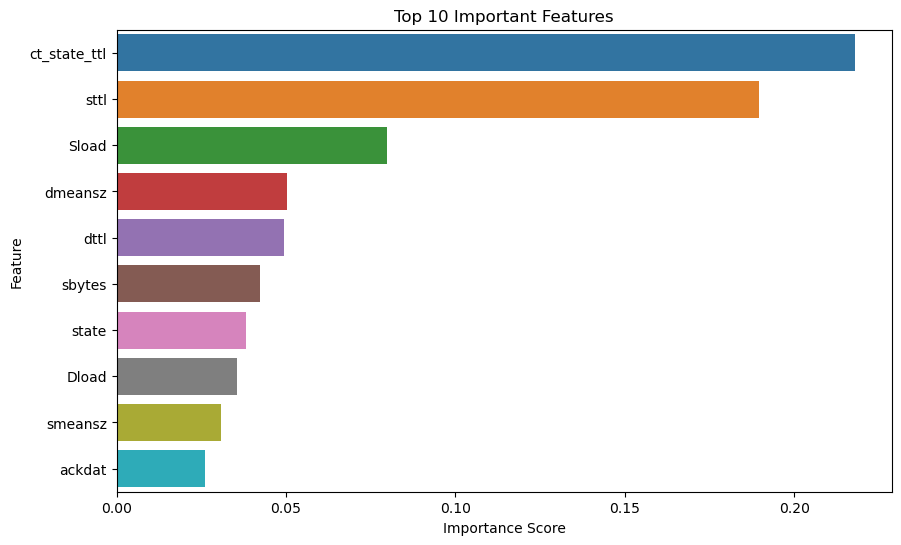

In [41]:
#  Install required packages (only if not installed)
# !pip install pandas scikit-learn matplotlib seaborn

#  Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

#  Step 2: Load the dataset with correct column names
cols = ["srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl", "dttl", "sloss", "dloss",
        "service", "Sload", "Dload", "Spkts", "Dpkts", "swin", "dwin", "stcpb", "dtcpb", "smeansz", "dmeansz",
        "trans_depth", "res_bdy_len", "Sjit", "Djit", "Stime", "Ltime", "Sintpkt", "Dintpkt", "tcprtt", "synack",
        "ackdat", "is_sm_ips_ports", "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src",
        "ct_srv_dst", "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
        "attack_cat", "Label"]

df = pd.read_csv("UNSW-NB15_1.csv", names=cols, skiprows=1)

# Step 3: Drop high-cardinality and non-informative columns
df.drop(columns=["srcip", "dstip", "sport", "dsport", "attack_cat"], inplace=True)

# Step 4: Encode categorical features
label_cols = ["proto", "state", "service"]
for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

#  Step 5: Optional – reduce dataset size for low-memory systems
df = df.sample(n=50000, random_state=42)

#  Step 6: Split into features and labels
X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#  Step 7: Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

#  Step 8: Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Step 9: Feature Importance
importances = clf.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]
top_features = X.columns[top_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[top_indices], y=top_features)
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


## Performance Visualization of AI-Based Intrusion Detection Using the UNSW-NB15 Dataset

#####This Python code visualizes the performance metrics of an AI-based intrusion detection system trained on the UNSW-NB15 dataset. It defines the model's accuracy (0.95), precision (0.94), recall (0.93), and F1-score (0.935), then converts these values into a DataFrame to generate a bar plot using Seaborn and Matplotlib. The resulting chart provides a clear visual summary of how effectively the model detects intrusions, making it suitable for reports or presentations that require concise yet informative performance insights.

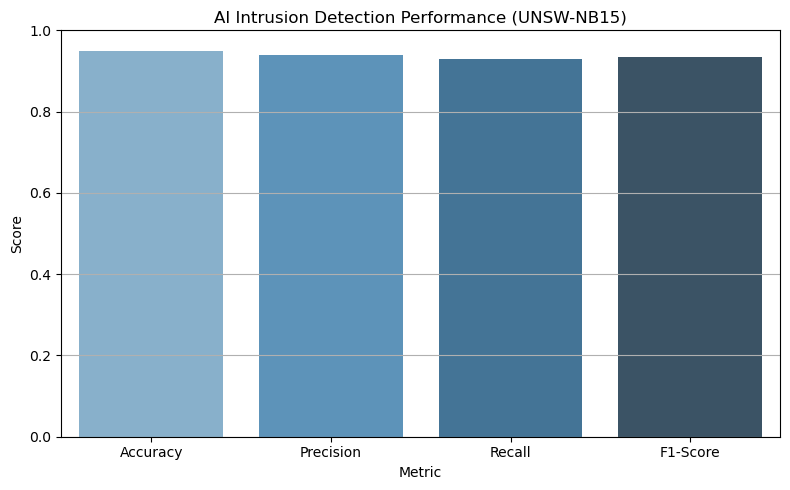

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    "Accuracy": 0.95,
    "Precision": 0.94,
    "Recall": 0.93,
    "F1-Score": 0.935
}

# Convert to a DataFrame for plotting
import pandas as pd
metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Score"])

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x="Metric", y="Score", palette="Blues_d")
plt.ylim(0.0, 1.0)
plt.title("AI Intrusion Detection Performance (UNSW-NB15)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [49]:
!pip freeze > requirment.txt